In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

In [4]:
df = pd.read_csv('../../data/hj_andrews_clean.csv')
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.set_index('DATE_TIME')
df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8


In [5]:
set(df.columns)

{'PA002',
 'PA003',
 'PA004',
 'PA005',
 'PA006',
 'PA009',
 'PA010',
 'PA011',
 'PA012',
 'PA013',
 'PA016',
 'PA017',
 'PA018',
 'PA019',
 'PA020',
 'PA021',
 'PA023',
 'PA027',
 'PA028',
 'PA029',
 'PA031',
 'PA032',
 'PA036',
 'PA037',
 'PA038',
 'PA039',
 'PA040',
 'PA041',
 'PA042',
 'PA044',
 'PA045',
 'PA048',
 'PA051',
 'PA053',
 'PA054',
 'PA059',
 'PA062',
 'PA063',
 'PA064',
 'PA065',
 'PA066',
 'PA076',
 'PA077',
 'PA078',
 'PA079',
 'PA080',
 'PA081',
 'PA200',
 'PA203',
 'PA204',
 'PA207',
 'PA208',
 'PA209',
 'PA210',
 'PA211',
 'PA217',
 'PA224',
 'PA226',
 'PA233',
 'PA234',
 'PA235',
 'PA239',
 'PA240',
 'PA241',
 'PA243',
 'PA245',
 'PA246',
 'PA247',
 'PA248',
 'PA249',
 'PA250',
 'PA252',
 'PA253',
 'PA256',
 'PA257',
 'PA258',
 'PA259',
 'PA260',
 'PA265',
 'PA266',
 'PA270',
 'PA272',
 'PA273',
 'PA274',
 'PA275',
 'PA276',
 'PA277',
 'PA279',
 'PA303',
 'PA304',
 'PA305',
 'PA306',
 'PA307',
 'PA308',
 'PA309',
 'PA310',
 'PA311',
 'PA312',
 'PA314',
 'PA315',


In [6]:
#df -= df.mean()
#df /= df.std()
df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8


In [7]:
noon_df = df[df.index.hour == 12]
noon_df = noon_df.resample('d').mean()
noon_df.index.freq = 'd'
noon_df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01,11.1,10.5,9.8,5.8,5.9,10.9,6.1,7.2,8.0,8.3,...,8.5,5.8,8.4,16.0,9.6,12.1,5.5,8.1,5.7,15.9
2011-05-02,4.7,4.4,4.2,2.9,2.2,4.5,3.3,3.6,3.3,1.2,...,0.6,0.6,0.7,6.8,5.6,4.4,1.7,3.4,2.9,1.5
2011-05-03,8.9,8.2,7.8,5.7,5.1,8.5,6.0,7.2,7.3,5.1,...,6.0,6.0,5.0,12.6,8.0,8.6,4.7,7.4,5.6,8.7
2011-05-04,15.1,14.1,14.3,9.9,8.3,14.8,10.1,12.1,13.3,11.6,...,11.8,9.0,13.0,20.1,13.7,16.0,7.9,13.4,9.7,19.3
2011-05-05,11.8,11.4,11.5,7.9,6.3,11.8,8.2,10.1,9.8,7.4,...,6.6,5.3,7.1,13.0,11.8,11.3,5.8,9.9,7.8,9.7


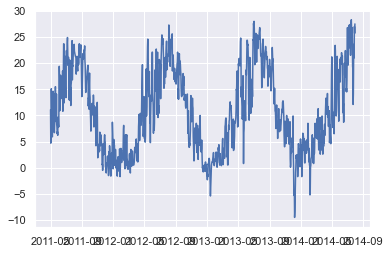

In [8]:
plt.plot(noon_df.iloc[:, 0])

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.structural import UnobservedComponents as UCM
from statsmodels.tsa.seasonal import STL

seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(noon_df.shape[1])):
    model = STL(noon_df.values[:, i], period=365)
    result = model.fit()
    seasonal_df[noon_df.columns[i]] = result.seasonal
    trend_df[noon_df.columns[i]] = result.trend
    resid_df[noon_df.columns[i]] = result.resid
seasonal_df.index = noon_df.index
trend_df.index = noon_df.index
resid_df.index = noon_df.index

  0%|          | 0/168 [00:00<?, ?it/s]

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_df[noon_df.columns[i]] = result.seasonal
/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  trend_df[noon_df.columns[i]] = result.trend
/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

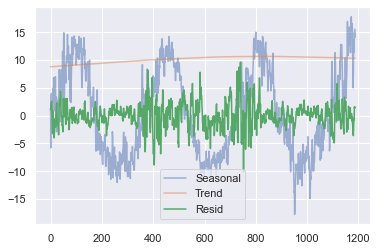

In [10]:
plt.plot(seasonal_df.values[:, 0], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, 0], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, 0], label='Resid')
plt.legend()

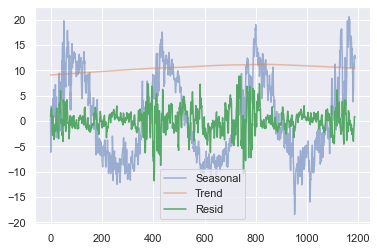

In [11]:
plt.plot(seasonal_df.values[:, 1], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, 1], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, 1], label='Resid')
plt.legend()

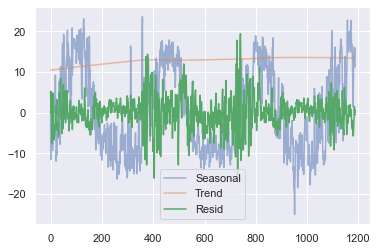

In [12]:
plt.plot(seasonal_df.values[:, -1], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, -1], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, -1], label='Resid')
plt.legend()

In [13]:
seasonal_df.shape, trend_df.shape, resid_df.shape

((1187, 168), (1187, 168), (1187, 168))

In [14]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
emp_cov = covariance.empirical_covariance(resid_scaled)
shrunk_cov = covariance.shrunk_covariance(emp_cov, shrinkage=0.8)
alphaRange = 10.0 ** np.arange(-8,0) # 1e-7 to 1e-1 by order of magnitude
for alpha in [0.1]:
    try: 
        graphCov = covariance.graphical_lasso(shrunk_cov, alpha)
        print("Calculated graph-lasso covariance matrix for alpha=%s"%alpha)
    except FloatingPointError:
        print("Failed at alpha=%s"%alpha)
ret = GraphicalLasso(max_iter=1000, alpha=0.1).fit(resid_scaled)

Calculated graph-lasso covariance matrix for alpha=0.1


In [15]:
ret.covariance_.max(), ret.precision_.max()

(1.0000000000000004, 9.359364560672386)

In [16]:
ret.precision_

array([[ 8.75840439, -0.52022797, -0.        , ..., -0.        ,
        -0.00978522, -0.        ],
       [-0.52022797,  7.2313805 , -0.        , ..., -0.        ,
        -0.05955819, -0.        ],
       [-0.        , -0.        ,  9.35936456, ..., -0.18011986,
        -0.        , -0.        ],
       ...,
       [-0.        , -0.        , -0.18011986, ...,  9.29834566,
        -0.22851352, -0.        ],
       [-0.00978522, -0.05955819, -0.        , ..., -0.22851352,
         8.70115756, -0.        ],
       [-0.        , -0.        , -0.        , ..., -0.        ,
        -0.        ,  3.23610607]])

<AxesSubplot:>

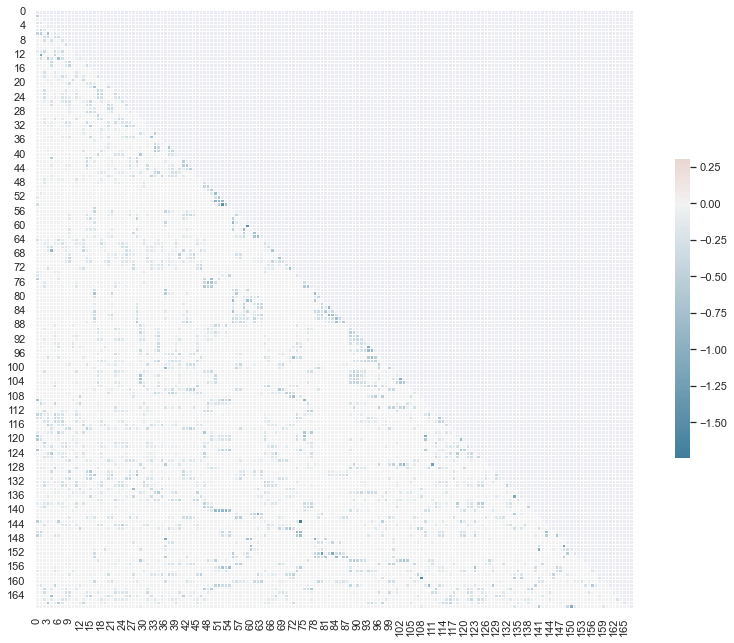

In [17]:
mask = np.triu(np.ones_like(ret.precision_, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ret.precision_, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

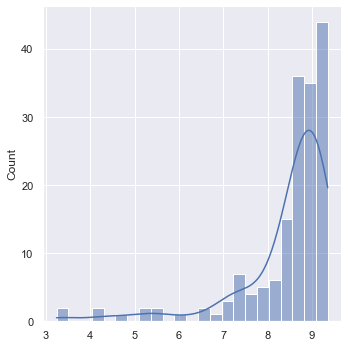

In [18]:
sns.displot(np.diag(ret.precision_), kde=True)

<AxesSubplot:ylabel='Count'>

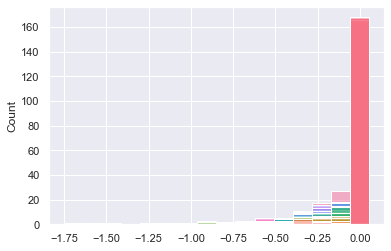

In [19]:
sns.histplot(np.triu(ret.precision_, k=1), legend=False)

<AxesSubplot:ylabel='Count'>

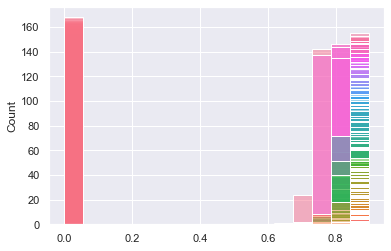

In [20]:
sns.histplot(np.triu(ret.covariance_, k=1), legend=False)

In [21]:
for i, col in enumerate(df.columns):
    print(i, col)

0 PA002
1 PA003
2 PA004
3 PA005
4 PA006
5 PA009
6 PA010
7 PA011
8 PA012
9 PA013
10 PA016
11 PA017
12 PA018
13 PA019
14 PA020
15 PA021
16 PA023
17 PA027
18 PA028
19 PA029
20 PA031
21 PA032
22 PA036
23 PA037
24 PA038
25 PA039
26 PA040
27 PA041
28 PA042
29 PA044
30 PA045
31 PA048
32 PA051
33 PA053
34 PA054
35 PA059
36 PA062
37 PA063
38 PA064
39 PA065
40 PA066
41 PA076
42 PA077
43 PA078
44 PA079
45 PA080
46 PA081
47 PA200
48 PA203
49 PA204
50 PA207
51 PA208
52 PA209
53 PA210
54 PA211
55 PA217
56 PA224
57 PA226
58 PA233
59 PA234
60 PA235
61 PA239
62 PA240
63 PA241
64 PA243
65 PA245
66 PA246
67 PA247
68 PA248
69 PA249
70 PA250
71 PA252
72 PA253
73 PA256
74 PA257
75 PA258
76 PA259
77 PA260
78 PA265
79 PA266
80 PA270
81 PA272
82 PA273
83 PA274
84 PA275
85 PA276
86 PA277
87 PA279
88 PA303
89 PA304
90 PA305
91 PA306
92 PA307
93 PA308
94 PA309
95 PA310
96 PA311
97 PA312
98 PA314
99 PA315
100 PA317
101 PA318
102 PA322
103 PA323
104 PA324
105 PA327
106 PA328
107 PA329
108 PA330
109 PA334
110 PA336


In [22]:
ret.precision_[75].argmax()

75

In [23]:
np.unravel_index(np.abs(ret.precision_[75]).argsort(axis=None), shape=ret.precision_[75].shape)

(array([ 83, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112,
        114, 115, 116,  99,  98,  97,  96,  80,  81,  82, 166,  84,  85,
         86, 117,  87,  89,  90,  91,  92,  93,  94,  95,  88,  79, 121,
        123, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
        163, 164, 165, 149, 148, 147, 146, 125, 126, 127, 129, 130, 131,
        132, 122, 133, 135, 136, 137, 141, 142, 144, 145, 134,  78, 167,
         37,  29,  30,  31,  32,  33,  34,  28,  35,   8,  38,   7,   5,
         39,  11,  36,  41,  27,  25,  12,  13,  14,  15,  16,  17,  26,
         18,  20,  21,  22,  23,   9,  24,  19,  42,  40,  43,  60,  61,
         62,  63,  65,  66,  58,  67,  69,  70,  71,  72,  74,   1,  68,
         57,  59,  55,  54,  44,  45,   4,  52,   2,  46,   3,  56, 143,
         48,  50,  73,  64, 128, 124,  10,  53, 113, 140,   6, 162, 139,
         76,  51, 138,  47, 120,   0,  77, 118,  49, 119, 109,  75]),)

In [24]:
ret.precision_[75][49]

-0.8047446709854136

In [25]:
np.unravel_index(np.abs(ret.covariance_[75]).argsort(axis=None), shape=ret.covariance_[75].shape)

(array([167, 150,  10,  60,  81, 149, 148, 151,  19, 159,  59,  78, 152,
         83,  82,  55, 141, 153,  80,  36,  84, 136,  12,  79,  58, 108,
         27,  62,  85,  61,  16,  86, 129,  87,  63, 134, 160,  28, 130,
         74, 127,  56,  21,  42, 100,  15, 156, 103,  41,  57, 142, 143,
        106,  68,  43, 158,  14, 131, 155, 111,  72, 145, 164,  46,  99,
         69,   1,  29,  26,  97,   9,  20, 117,  38,  44,  32,  37,   4,
         71, 126,  96,  70, 107,  52, 102, 146,  94,  35,  40,  25,  67,
         54,  95,  31,  33,  93,  66, 116,  45,  34, 163, 105, 137,   3,
        166,   8,  39,  24, 161,  53,  13,  98, 154, 144,  17, 135, 104,
         65,  22,  50,  23,  89,  92, 140, 114, 165, 122, 123,  90,   5,
         18, 110, 147,  73,  91, 121, 133,  88, 124,   7,  51, 125,  30,
          2, 115, 157,   6, 112, 101,  64,  48, 132,  11, 128, 162, 113,
        139, 138,  76,  47,   0,  77, 120, 118, 119, 109,  49,  75]),)

In [26]:
latlong = pd.read_csv("../../data/HJA_xy_coord_elv_bird_pts.csv")
latlong.head()

,Plot,PlotNum,X,Y,Elv (m)
0,2,2,563755,4897830,603.23
1,3,3,563755,4897530,648.59
2,4,4,563755,4897230,766.32
3,5,5,563755,4896630,912.25
4,6,6,563755,4896330,993.51


In [27]:
latlong.tail()

,Plot,PlotNum,X,Y,Elv (m)
180,PC14,514,567112,4900997,964.51
181,PC15,515,566230,4901776,970.79
182,PC16,516,565617,4901912,1030.05
183,PC17,517,568874,4902589,1301.42
184,PC18,518,569010,4902722,1338.87


In [28]:
latlong_df = latlong[~latlong['Plot'].str.contains("PC")]
latlong_df.tail()

,Plot,PlotNum,X,Y,Elv (m)
162,354,354,561686,4895983,843.02
163,356,356,562384,4895868,885.60
164,357,357,562681,4895810,873.27
165,358,358,570678,4895092,1310.27
166,400,400,567657,4895416,1055.28


In [29]:
sorted(list(set(df.columns)))

['PA002',
 'PA003',
 'PA004',
 'PA005',
 'PA006',
 'PA009',
 'PA010',
 'PA011',
 'PA012',
 'PA013',
 'PA016',
 'PA017',
 'PA018',
 'PA019',
 'PA020',
 'PA021',
 'PA023',
 'PA027',
 'PA028',
 'PA029',
 'PA031',
 'PA032',
 'PA036',
 'PA037',
 'PA038',
 'PA039',
 'PA040',
 'PA041',
 'PA042',
 'PA044',
 'PA045',
 'PA048',
 'PA051',
 'PA053',
 'PA054',
 'PA059',
 'PA062',
 'PA063',
 'PA064',
 'PA065',
 'PA066',
 'PA076',
 'PA077',
 'PA078',
 'PA079',
 'PA080',
 'PA081',
 'PA200',
 'PA203',
 'PA204',
 'PA207',
 'PA208',
 'PA209',
 'PA210',
 'PA211',
 'PA217',
 'PA224',
 'PA226',
 'PA233',
 'PA234',
 'PA235',
 'PA239',
 'PA240',
 'PA241',
 'PA243',
 'PA245',
 'PA246',
 'PA247',
 'PA248',
 'PA249',
 'PA250',
 'PA252',
 'PA253',
 'PA256',
 'PA257',
 'PA258',
 'PA259',
 'PA260',
 'PA265',
 'PA266',
 'PA270',
 'PA272',
 'PA273',
 'PA274',
 'PA275',
 'PA276',
 'PA277',
 'PA279',
 'PA303',
 'PA304',
 'PA305',
 'PA306',
 'PA307',
 'PA308',
 'PA309',
 'PA310',
 'PA311',
 'PA312',
 'PA314',
 'PA315',


In [30]:
df_nums = [x[2:] for x in list(df.columns)]
df_nums

['002',
 '003',
 '004',
 '005',
 '006',
 '009',
 '010',
 '011',
 '012',
 '013',
 '016',
 '017',
 '018',
 '019',
 '020',
 '021',
 '023',
 '027',
 '028',
 '029',
 '031',
 '032',
 '036',
 '037',
 '038',
 '039',
 '040',
 '041',
 '042',
 '044',
 '045',
 '048',
 '051',
 '053',
 '054',
 '059',
 '062',
 '063',
 '064',
 '065',
 '066',
 '076',
 '077',
 '078',
 '079',
 '080',
 '081',
 '200',
 '203',
 '204',
 '207',
 '208',
 '209',
 '210',
 '211',
 '217',
 '224',
 '226',
 '233',
 '234',
 '235',
 '239',
 '240',
 '241',
 '243',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '252',
 '253',
 '256',
 '257',
 '258',
 '259',
 '260',
 '265',
 '266',
 '270',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '279',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '314',
 '315',
 '317',
 '318',
 '322',
 '323',
 '324',
 '327',
 '328',
 '329',
 '330',
 '334',
 '336',
 '338',
 '339',
 '340',
 '341',
 '342',
 '344',
 '345',
 '347',
 '348',
 '349',
 '350',
 '351',
 '352',
 '353',


In [31]:
latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]
latlong_df.head()

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/812741481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]


,Plot,PlotNum,X,Y,Elv (m)
0,002,2,563755,4897830,603.23
1,003,3,563755,4897530,648.59
2,004,4,563755,4897230,766.32
3,005,5,563755,4896630,912.25
4,006,6,563755,4896330,993.51


In [32]:
latlong_df.tail()

,Plot,PlotNum,X,Y,Elv (m)
162,354,354,561686,4895983,843.02
163,356,356,562384,4895868,885.60
164,357,357,562681,4895810,873.27
165,358,358,570678,4895092,1310.27
166,400,400,567657,4895416,1055.28


In [33]:
df

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-07-30 19:00:00,25.0,26.1,27.8,26.5,25.7,27.5,26.1,26.6,26.2,23.7,...,22.3,23.1,23.7,29.2,27.3,27.7,23.4,26.5,25.9,25.6
2014-07-30 20:00:00,23.9,25.1,25.5,25.4,24.8,26.4,25.1,25.6,24.0,21.9,...,20.3,21.1,21.9,26.5,25.1,25.3,22.5,24.3,24.9,21.0
2014-07-30 21:00:00,22.7,22.9,23.2,23.1,22.5,24.1,22.8,23.3,21.9,20.1,...,18.3,18.8,20.0,23.9,22.9,23.1,21.5,22.1,22.6,18.8


In [34]:
latlong_df.shape

(167, 5)

In [35]:
set(df_nums) - set(latlong_df["Plot"])

{'506'}

In [36]:
df_copy = df.copy()
df_copy.columns = df_nums
df_copy = df_copy.loc[:, df_copy.columns != '506']
df_copy.shape

(28487, 167)

In [37]:
set(df_copy.columns) - set(latlong_df["Plot"])

set()

In [38]:
df_copy_sorted = df_copy.sort_index(axis=1)
df_copy_sorted.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,-0.4,0.5,0.7,0.5,0.6,...,-0.3,0.3,0.7,-0.1,0.7,1.0,0.7,0.2,-2.7,0.0
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,-0.7,0.2,0.4,0.3,0.3,...,-0.6,0.3,0.3,-0.6,0.5,0.7,0.4,-0.1,-3.0,-0.3
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,-0.9,0.1,0.3,0.3,0.3,...,-0.8,0.0,0.3,-1.1,0.2,0.4,0.3,-0.1,-3.3,-0.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-1.1,-0.1,0.2,0.2,0.1,...,-1.0,-0.6,0.1,-1.3,-0.1,0.1,0.2,-0.3,-3.5,-0.6
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-1.3,-0.1,-0.1,0.1,-0.1,...,-1.1,-0.7,0.0,-1.5,-0.3,-0.1,0.0,-0.5,-3.8,-0.6


In [39]:
noon_df = df_copy_sorted[df_copy_sorted.index.hour == 12]
noon_df = noon_df.resample('d').mean()
noon_df.index.freq = 'd'
noon_df.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01,11.1,10.5,9.8,5.8,5.9,13.4,10.9,6.1,7.2,8.0,...,13.2,9.3,8.2,14.5,7.4,7.8,8.1,5.7,15.9,8.4
2011-05-02,4.7,4.4,4.2,2.9,2.2,5.3,4.5,3.3,3.6,3.3,...,5.3,5.3,3.4,6.3,3.9,4.3,3.4,2.9,1.5,1.4
2011-05-03,8.9,8.2,7.8,5.7,5.1,10.1,8.5,6.0,7.2,7.3,...,10.0,7.6,7.4,11.8,7.7,8.2,7.4,5.6,8.7,5.3
2011-05-04,15.1,14.1,14.3,9.9,8.3,17.2,14.8,10.1,12.1,13.3,...,16.9,13.5,13.5,18.0,11.7,12.2,13.4,9.7,19.3,11.7
2011-05-05,11.8,11.4,11.5,7.9,6.3,12.7,11.8,8.2,10.1,9.8,...,12.5,11.5,9.9,11.9,9.8,10.3,9.9,7.8,9.7,7.5


In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.structural import UnobservedComponents as UCM
from statsmodels.tsa.seasonal import STL

seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(noon_df.shape[1])):
    model = STL(noon_df.values[:, i], period=365)
    result = model.fit()
    seasonal_df[noon_df.columns[i]] = result.seasonal
    trend_df[noon_df.columns[i]] = result.trend
    resid_df[noon_df.columns[i]] = result.resid
seasonal_df.index = noon_df.index
trend_df.index = noon_df.index
resid_df.index = noon_df.index

  0%|          | 0/167 [00:00<?, ?it/s]

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_df[noon_df.columns[i]] = result.seasonal
/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  trend_df[noon_df.columns[i]] = result.trend
/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/85624581.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

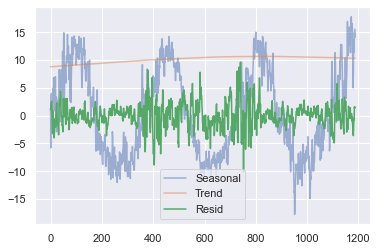

In [41]:
plt.plot(seasonal_df.values[:, 0], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, 0], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, 0], label='Resid')
plt.legend()

In [42]:
seasonal_df.shape, trend_df.shape, resid_df.shape

((1187, 167), (1187, 167), (1187, 167))

In [61]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
emp_cov = covariance.empirical_covariance(resid_scaled)
shrunk_cov = covariance.shrunk_covariance(emp_cov, shrinkage=0.8)
alphaRange = 10.0 ** np.arange(-8,0) # 1e-7 to 1e-1 by order of magnitude
for alpha in [0.1]:
    try: 
        graphCov = covariance.graphical_lasso(shrunk_cov, alpha)
        print("Calculated graph-lasso covariance matrix for alpha=%s"%alpha)
    except FloatingPointError:
        print("Failed at alpha=%s"%alpha)
ret = GraphicalLasso(max_iter=1000, alpha=0.8, tol=1e-5).fit(resid_scaled)

Calculated graph-lasso covariance matrix for alpha=0.1


In [62]:
ret.covariance_.max(), ret.precision_.max()

(1.0000000000000004, 1.2288842396876813)

<AxesSubplot:>

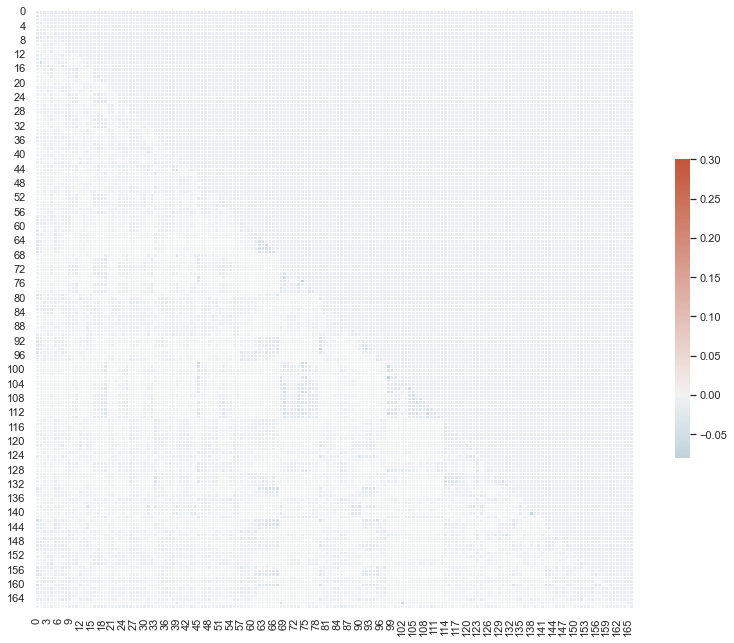

In [63]:
mask = np.triu(np.ones_like(ret.precision_, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ret.precision_, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

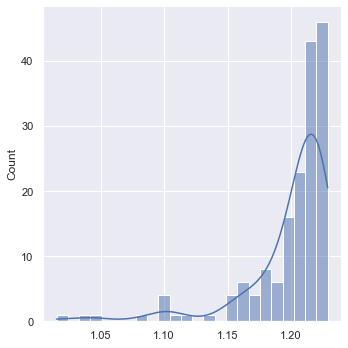

In [64]:
sns.displot(np.diag(ret.precision_), kde=True)

<AxesSubplot:ylabel='Count'>

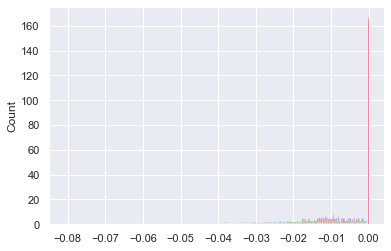

In [65]:
sns.histplot(np.triu(ret.precision_, k=1), legend=False)

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/971228450.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Elevation')


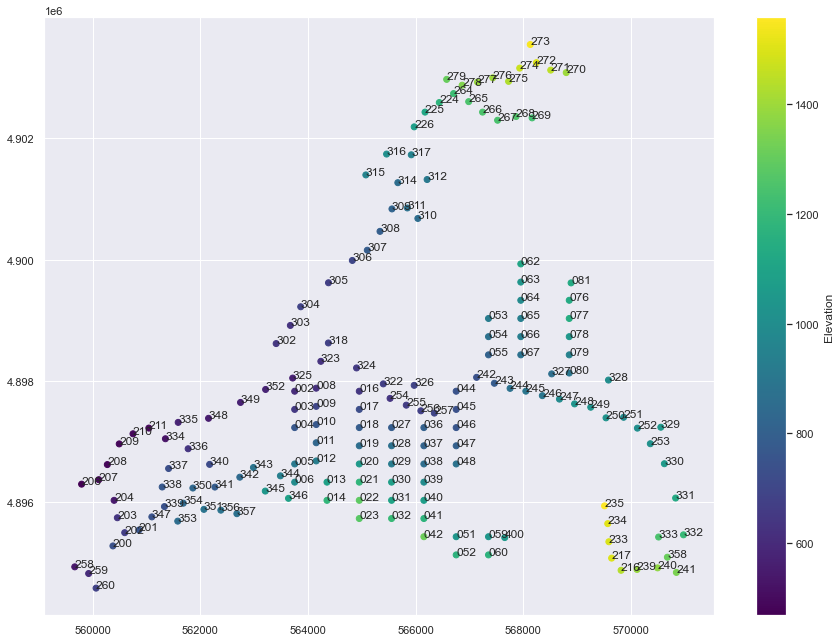

In [66]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], y=latlong_df['Y'], c=latlong_df['Elv (m)'], cmap='viridis')
plt.colorbar(label='Elevation')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [67]:
import networkx as nx 
G = nx.DiGraph()
for i in range(ret.precision_.shape[0]): 
    for j in range(ret.precision_.shape[1]):
        if i == j:
            continue
        elif np.abs(ret.precision_[i][j]) != 0.:
              G.add_edge(i,j)

ModuleNotFoundError: No module named 'networkx'

In [49]:
nx.draw( G ) 
plt.show() 

NameError: name 'nx' is not defined

In [68]:
top_ks = []
for i in range(ret.precision_.shape[0]):
    top_5 = np.unravel_index(np.abs(ret.precision_[i]).argsort(axis=None), shape=ret.precision_[i].shape)[0][-6:-1]
    top_ks.append(top_5)
top_ks = np.array(top_ks)
top_ks.shape

(167, 5)

In [69]:
np.unravel_index(np.abs(ret.precision_[0]).argsort(axis=None), shape=ret.precision_[0].shape)[0][-6:-1]

array([157, 160, 156,  79, 142])

In [70]:
latlong_df

,Plot,PlotNum,X,Y,Elv (m)
0,002,2,563755,4897830,603.23
1,003,3,563755,4897530,648.59
2,004,4,563755,4897230,766.32
3,005,5,563755,4896630,912.25
4,006,6,563755,4896330,993.51
...,...,...,...,...,...
162,354,354,561686,4895983,843.02
163,356,356,562384,4895868,885.60
164,357,357,562681,4895810,873.27
165,358,358,570678,4895092,1310.27


In [71]:
precision = ret.precision_.copy()
precision[precision==-0.0] = 999
precision -= precision.min()
precision

array([[1.28479947e+00, 5.16957257e-02, 7.24497653e-02, ...,
        6.54607719e-02, 9.99080932e+02, 9.99080932e+02],
       [5.16957257e-02, 1.25384531e+00, 6.96158912e-02, ...,
        6.45802502e-02, 9.99080932e+02, 9.99080932e+02],
       [7.24497653e-02, 6.96158912e-02, 1.30725017e+00, ...,
        7.22171034e-02, 9.99080932e+02, 7.22305349e-02],
       ...,
       [6.54607719e-02, 6.45802502e-02, 7.22171034e-02, ...,
        1.29382593e+00, 9.99080932e+02, 7.58489325e-02],
       [9.99080932e+02, 9.99080932e+02, 9.99080932e+02, ...,
        9.99080932e+02, 1.09627452e+00, 9.99080932e+02],
       [9.99080932e+02, 9.99080932e+02, 7.22305349e-02, ...,
        7.58489325e-02, 9.99080932e+02, 1.30792313e+00]])

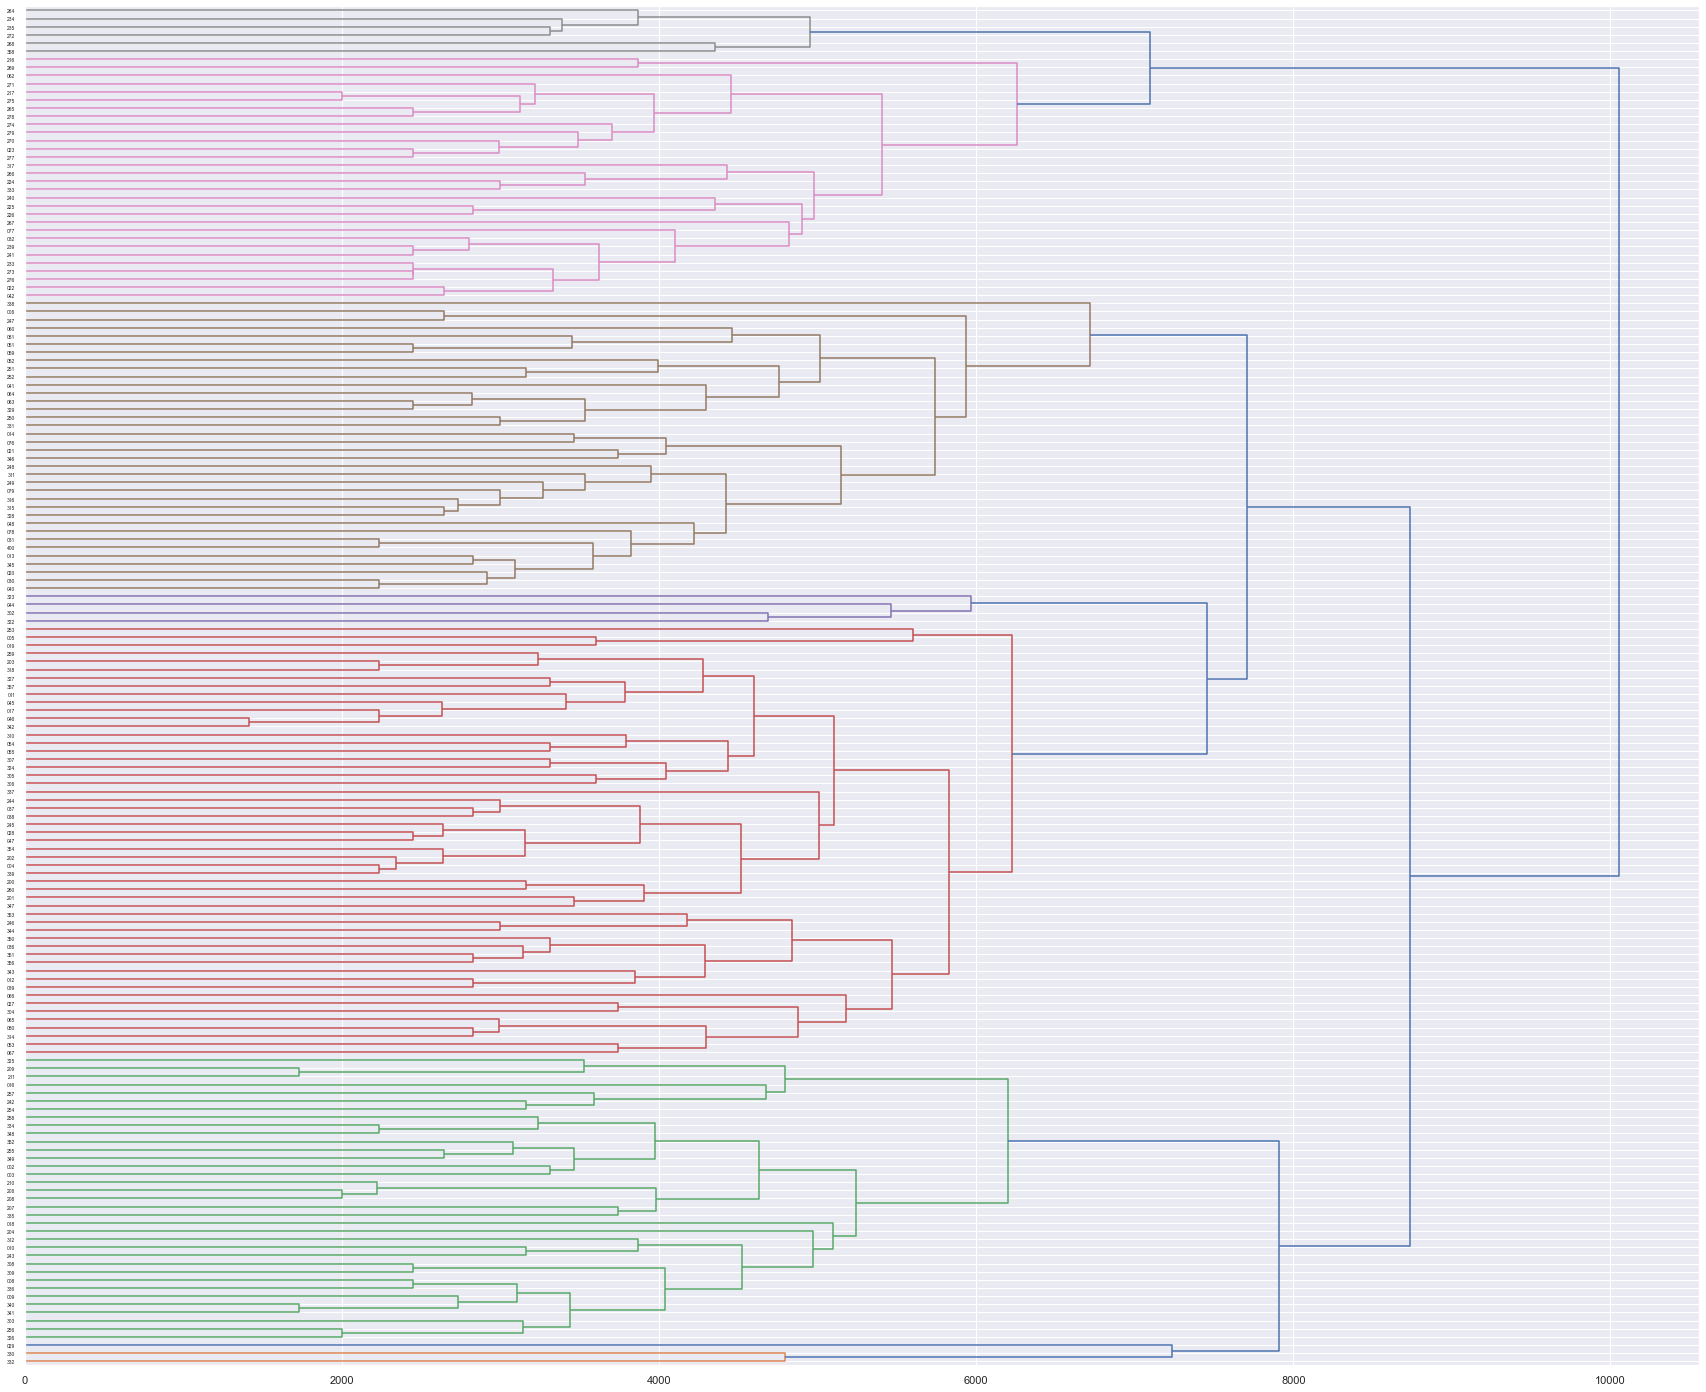

In [72]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
Z = linkage(precision,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [73]:
#cluster_labels = fcluster(Z, t=1.154)
cluster_labels = fcluster(Z, t=1.154)
num_clusters = len(list(set(cluster_labels)))
cluster_labels, num_clusters

(array([13, 13,  8,  4,  2, 15, 15, 15,  5, 11,  2,  2, 12,  5, 15,  4,  2,
         2,  1,  1, 11,  7, 16,  2,  2,  1, 11,  6,  6, 11,  2,  2,  1,  3,
         5,  5,  7,  2,  2,  2, 11,  5,  5,  2,  2,  1,  2,  2, 11, 11, 11,
         2,  1,  2,  2, 11,  2,  9,  9,  8,  5, 15, 14, 14, 14, 12, 14, 12,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 12, 15,  6,  7, 11,  2,
         2,  2,  2,  2,  2,  4, 12, 13, 15, 12, 13,  5,  9,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  3, 15, 11,  5,  5,
         5, 15, 15,  5,  2, 15, 11,  2,  2,  1,  5,  3,  3,  5, 12, 15,  5,
         2,  2, 16,  2, 16,  1, 13, 14, 15, 10,  2,  8, 15, 15,  5, 11, 11,
         2,  2,  9, 13, 13, 11, 11, 13, 11,  8, 11,  5,  1,  2],
       dtype=int32),
 16)

In [74]:
latlong_df['Cluster'] = cluster_labels
latlong_df

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/1956568068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latlong_df['Cluster'] = cluster_labels


,Plot,PlotNum,X,Y,Elv (m),Cluster
0,002,2,563755,4897830,603.23,13
1,003,3,563755,4897530,648.59,13
2,004,4,563755,4897230,766.32,8
3,005,5,563755,4896630,912.25,4
4,006,6,563755,4896330,993.51,2
...,...,...,...,...,...,...
162,354,354,561686,4895983,843.02,8
163,356,356,562384,4895868,885.60,11
164,357,357,562681,4895810,873.27,5
165,358,358,570678,4895092,1310.27,1


/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/2551252743.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


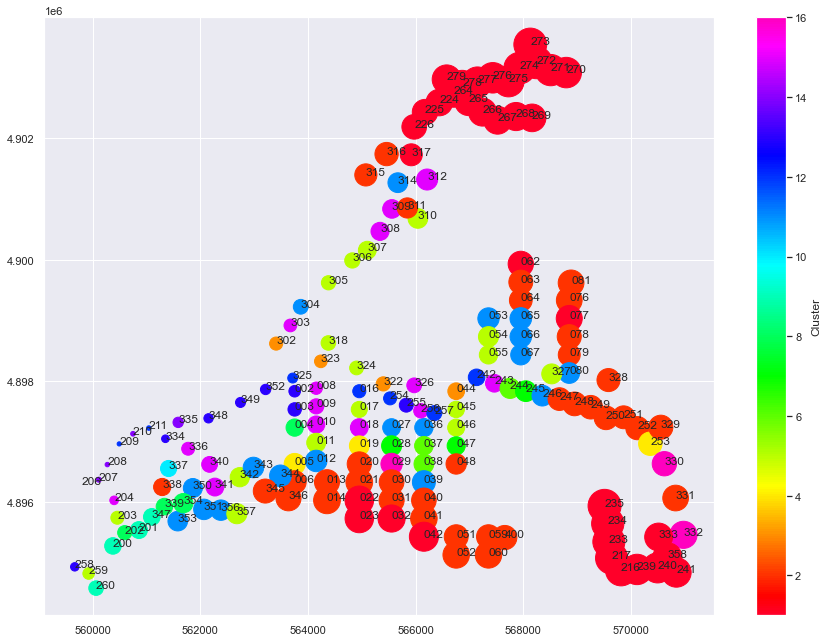

In [75]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=latlong_df['Cluster'], 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [76]:
numclust = 6
f = fcluster(Z,numclust,criterion='maxclust')
f.shape

(167,)

In [77]:
latlong_df['Cluster'] = f
latlong_df.head()

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/164755815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latlong_df['Cluster'] = f


,Plot,PlotNum,X,Y,Elv (m),Cluster
0,002,2,563755,4897830,603.23,5
1,003,3,563755,4897530,648.59,5
2,004,4,563755,4897230,766.32,4
3,005,5,563755,4896630,912.25,4
4,006,6,563755,4896330,993.51,2


/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/2551252743.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


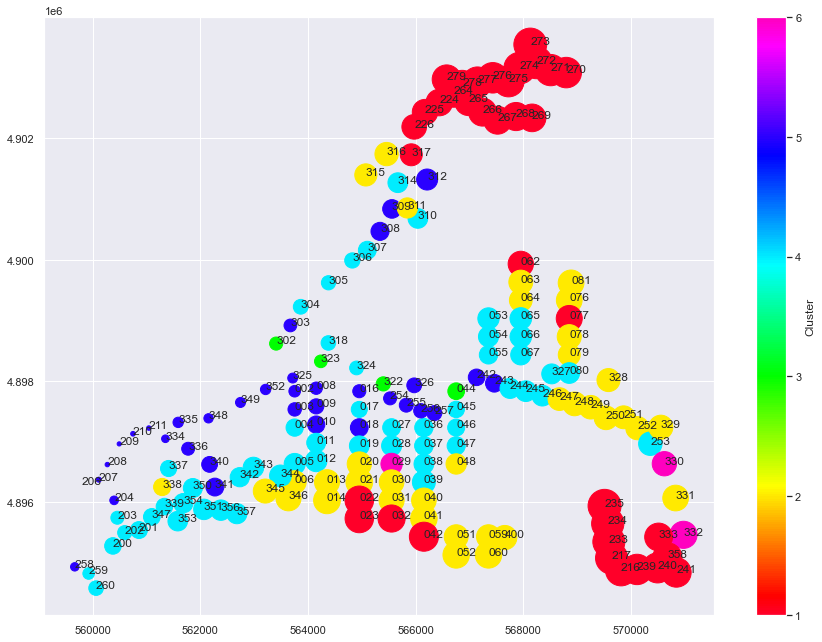

In [78]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=latlong_df['Cluster'], 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [79]:
from scipy.cluster import hierarchy
cutree1 = hierarchy.cut_tree(Z, n_clusters=10).squeeze()
cutree1

array([0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 3, 3, 1, 1,
       4, 2, 2, 3, 1, 1, 1, 1, 2, 2, 3, 5, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       2, 3, 2, 2, 1, 1, 1, 2, 3, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 6, 3, 3, 3, 3, 3, 7, 7, 3, 3, 3, 0, 0, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 7, 3, 3, 3, 7, 6, 3, 3, 7, 3, 3, 3,
       3, 3, 3, 3, 5, 0, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 3, 1, 5, 5,
       1, 0, 0, 1, 2, 2, 8, 2, 8, 3, 0, 0, 0, 1, 9, 1, 0, 0, 1, 1, 1, 2,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 7, 2])

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


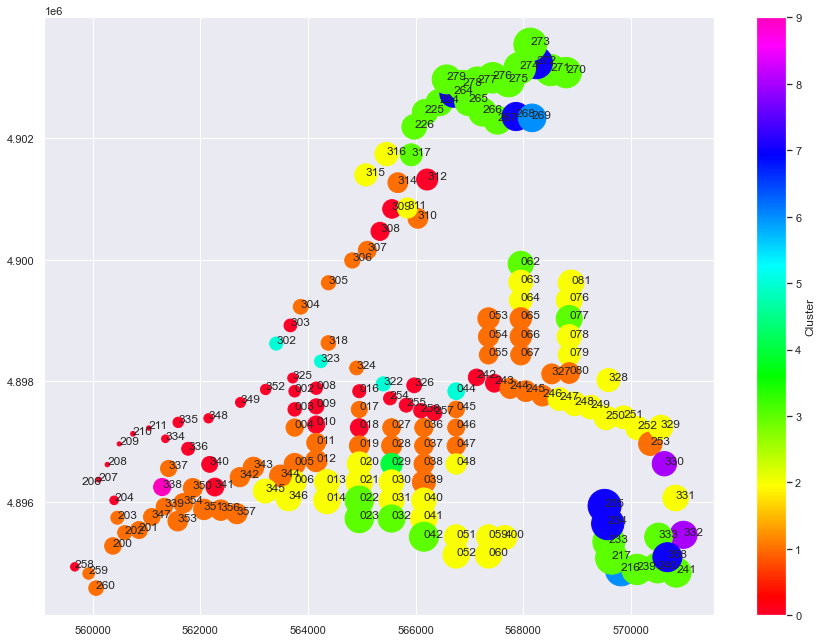

In [80]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [81]:
np.triu(ret.precision_, k=1).min()

-0.08093172118404607

In [82]:
np.triu(ret.covariance_, k=1).min()

0.0

In [83]:
latlong_df["Plot"][cutree1 == 0]

0      002
1      003
5      008
6      009
7      010
12     016
14     018
61     204
62     206
63     207
64     208
65     209
66     210
67     211
79     242
80     243
91     254
92     255
93     256
94     257
95     258
115    303
120    308
121    309
124    312
133    325
134    326
142    334
143    335
144    336
148    340
149    341
156    348
157    349
160    352
Name: Plot, dtype: object

In [84]:
cutree1

array([0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 3, 3, 1, 1,
       4, 2, 2, 3, 1, 1, 1, 1, 2, 2, 3, 5, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       2, 3, 2, 2, 1, 1, 1, 2, 3, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 6, 3, 3, 3, 3, 3, 7, 7, 3, 3, 3, 0, 0, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 7, 3, 3, 3, 7, 6, 3, 3, 7, 3, 3, 3,
       3, 3, 3, 3, 5, 0, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 3, 1, 5, 5,
       1, 0, 0, 1, 2, 2, 8, 2, 8, 3, 0, 0, 0, 1, 9, 1, 0, 0, 1, 1, 1, 2,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 7, 2])

In [85]:
def is_pos_def(A):
    if np.allclose(A, A.T):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

In [86]:
prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2] # set i,j entry to be the entry from precision matrix for given cluster
            print(idx, idx2)
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)

0 0
0 1
0 5
0 6
0 7
0 12
0 14
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 79
0 80
0 91
0 92
0 93
0 94
0 95
0 115
0 120
0 121
0 124
0 133
0 134
0 142
0 143
0 144
0 148
0 149
0 156
0 157
0 160
1 0
1 1
1 5
1 6
1 7
1 12
1 14
1 61
1 62
1 63
1 64
1 65
1 66
1 67
1 79
1 80
1 91
1 92
1 93
1 94
1 95
1 115
1 120
1 121
1 124
1 133
1 134
1 142
1 143
1 144
1 148
1 149
1 156
1 157
1 160
5 0
5 1
5 5
5 6
5 7
5 12
5 14
5 61
5 62
5 63
5 64
5 65
5 66
5 67
5 79
5 80
5 91
5 92
5 93
5 94
5 95
5 115
5 120
5 121
5 124
5 133
5 134
5 142
5 143
5 144
5 148
5 149
5 156
5 157
5 160
6 0
6 1
6 5
6 6
6 7
6 12
6 14
6 61
6 62
6 63
6 64
6 65
6 66
6 67
6 79
6 80
6 91
6 92
6 93
6 94
6 95
6 115
6 120
6 121
6 124
6 133
6 134
6 142
6 143
6 144
6 148
6 149
6 156
6 157
6 160
7 0
7 1
7 5
7 6
7 7
7 12
7 14
7 61
7 62
7 63
7 64
7 65
7 66
7 67
7 79
7 80
7 91
7 92
7 93
7 94
7 95
7 115
7 120
7 121
7 124
7 133
7 134
7 142
7 143
7 144
7 148
7 149
7 156
7 157
7 160
12 0
12 1
12 5
12 6
12 7
12 12
12 14
12 61
12 62
12 63
12 64
12 65
12 66
12 67
1

27 60
27 81
27 82
27 83
27 90
27 96
27 97
27 116
27 117
27 118
27 119
27 122
27 125
27 129
27 132
27 135
27 145
27 147
27 150
27 151
27 152
27 155
27 158
27 159
27 161
27 162
27 163
27 164
28 2
28 3
28 8
28 9
28 13
28 15
28 20
28 21
28 26
28 27
28 28
28 29
28 34
28 35
28 36
28 40
28 41
28 42
28 48
28 49
28 50
28 55
28 57
28 58
28 59
28 60
28 81
28 82
28 83
28 90
28 96
28 97
28 116
28 117
28 118
28 119
28 122
28 125
28 129
28 132
28 135
28 145
28 147
28 150
28 151
28 152
28 155
28 158
28 159
28 161
28 162
28 163
28 164
29 2
29 3
29 8
29 9
29 13
29 15
29 20
29 21
29 26
29 27
29 28
29 29
29 34
29 35
29 36
29 40
29 41
29 42
29 48
29 49
29 50
29 55
29 57
29 58
29 59
29 60
29 81
29 82
29 83
29 90
29 96
29 97
29 116
29 117
29 118
29 119
29 122
29 125
29 129
29 132
29 135
29 145
29 147
29 150
29 151
29 152
29 155
29 158
29 159
29 161
29 162
29 163
29 164
34 2
34 3
34 8
34 9
34 13
34 15
34 20
34 21
34 26
34 27
34 28
34 29
34 34
34 35
34 36
34 40
34 41
34 42
34 48
34 49
34 50
34 55
34 57
34 58
3

152 29
152 34
152 35
152 36
152 40
152 41
152 42
152 48
152 49
152 50
152 55
152 57
152 58
152 59
152 60
152 81
152 82
152 83
152 90
152 96
152 97
152 116
152 117
152 118
152 119
152 122
152 125
152 129
152 132
152 135
152 145
152 147
152 150
152 151
152 152
152 155
152 158
152 159
152 161
152 162
152 163
152 164
155 2
155 3
155 8
155 9
155 13
155 15
155 20
155 21
155 26
155 27
155 28
155 29
155 34
155 35
155 36
155 40
155 41
155 42
155 48
155 49
155 50
155 55
155 57
155 58
155 59
155 60
155 81
155 82
155 83
155 90
155 96
155 97
155 116
155 117
155 118
155 119
155 122
155 125
155 129
155 132
155 135
155 145
155 147
155 150
155 151
155 152
155 155
155 158
155 159
155 161
155 162
155 163
155 164
158 2
158 3
158 8
158 9
158 13
158 15
158 20
158 21
158 26
158 27
158 28
158 29
158 34
158 35
158 36
158 40
158 41
158 42
158 48
158 49
158 50
158 55
158 57
158 58
158 59
158 60
158 81
158 82
158 83
158 90
158 96
158 97
158 116
158 117
158 118
158 119
158 122
158 125
158 129
158 132
158 135
158 1

18 45
18 52
18 69
18 70
18 71
18 72
18 73
18 76
18 77
18 78
18 99
18 100
18 101
18 104
18 105
18 107
18 108
18 109
18 110
18 111
18 112
18 113
18 128
18 141
19 18
19 19
19 25
19 32
19 45
19 52
19 69
19 70
19 71
19 72
19 73
19 76
19 77
19 78
19 99
19 100
19 101
19 104
19 105
19 107
19 108
19 109
19 110
19 111
19 112
19 113
19 128
19 141
25 18
25 19
25 25
25 32
25 45
25 52
25 69
25 70
25 71
25 72
25 73
25 76
25 77
25 78
25 99
25 100
25 101
25 104
25 105
25 107
25 108
25 109
25 110
25 111
25 112
25 113
25 128
25 141
32 18
32 19
32 25
32 32
32 45
32 52
32 69
32 70
32 71
32 72
32 73
32 76
32 77
32 78
32 99
32 100
32 101
32 104
32 105
32 107
32 108
32 109
32 110
32 111
32 112
32 113
32 128
32 141
45 18
45 19
45 25
45 32
45 45
45 52
45 69
45 70
45 71
45 72
45 73
45 76
45 77
45 78
45 99
45 100
45 101
45 104
45 105
45 107
45 108
45 109
45 110
45 111
45 112
45 113
45 128
45 141
52 18
52 19
52 25
52 32
52 45
52 52
52 69
52 70
52 71
52 72
52 73
52 76
52 77
52 78
52 99
52 100
52 101
52 104
52 105
5

In [87]:
np.where(cutree1==1)

(array([  2,   3,   8,   9,  13,  15,  20,  21,  26,  27,  28,  29,  34,
         35,  36,  40,  41,  42,  48,  49,  50,  55,  57,  58,  59,  60,
         81,  82,  83,  90,  96,  97, 116, 117, 118, 119, 122, 125, 129,
        132, 135, 145, 147, 150, 151, 152, 155, 158, 159, 161, 162, 163,
        164]),)

In [88]:
(basis_matrices.sum(axis=0) == prec).sum()

17477

In [89]:
is_pos_def(basis_matrices.sum(axis=0))

True

In [90]:
from sklearn.cluster import SpectralCoclustering, SpectralBiclustering

clustering = SpectralBiclustering(n_clusters=10, random_state=0).fit(prec)
clustering.column_labels_

array([0, 8, 6, 1, 4, 8, 4, 7, 1, 7, 8, 8, 3, 5, 3, 1, 6, 2, 1, 4, 2, 9,
       3, 5, 7, 1, 7, 5, 4, 7, 8, 1, 9, 3, 3, 1, 5, 7, 7, 8, 2, 3, 1, 3,
       9, 4, 1, 4, 8, 2, 2, 6, 5, 9, 7, 4, 8, 5, 3, 3, 5, 4, 2, 9, 8, 2,
       3, 1, 0, 4, 4, 9, 3, 4, 3, 3, 8, 3, 9, 5, 6, 4, 8, 5, 8, 9, 9, 7,
       8, 0, 3, 9, 2, 0, 9, 4, 1, 2, 3, 2, 1, 3, 3, 3, 9, 8, 3, 2, 3, 7,
       1, 3, 0, 4, 6, 9, 8, 9, 6, 0, 1, 4, 4, 3, 7, 7, 5, 3, 6, 3, 0, 0,
       9, 3, 2, 1, 4, 8, 8, 4, 3, 8, 4, 1, 4, 5, 8, 2, 8, 2, 0, 7, 9, 2,
       0, 3, 2, 8, 7, 8, 8, 9, 5, 0, 8, 3, 0], dtype=int32)

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/2163141238.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


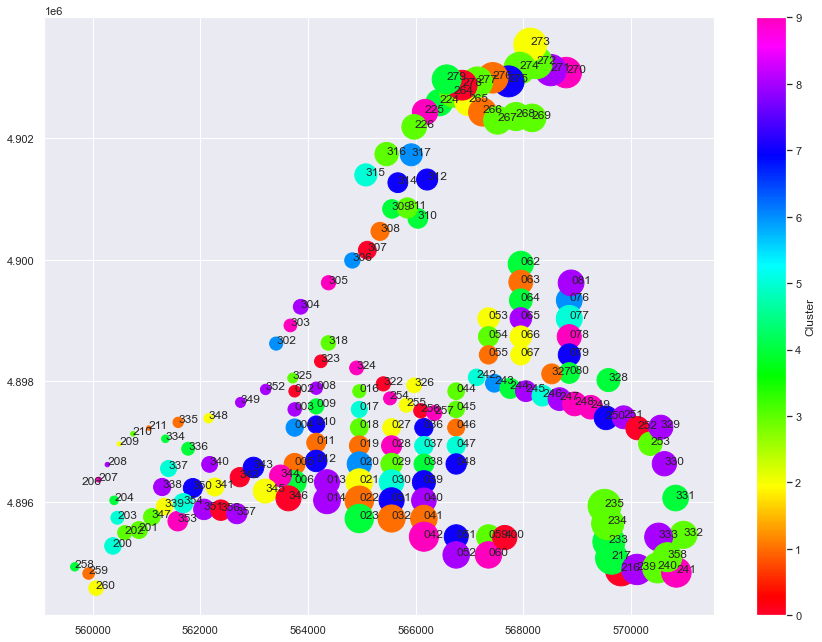

In [91]:
# biclustering column labels
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=clustering.column_labels_, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/1659652990.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


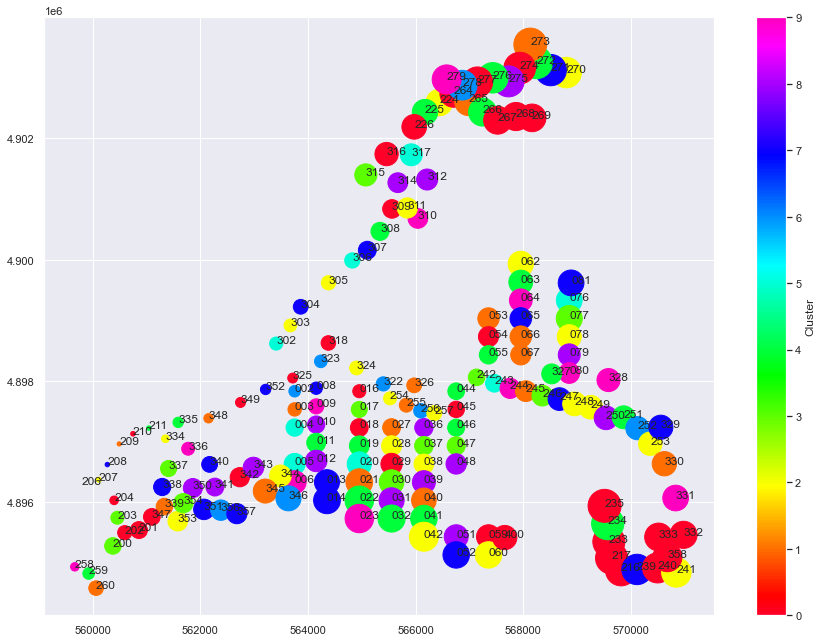

In [92]:
# biclustering row labels
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=clustering.row_labels_, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [93]:
clustering = SpectralCoclustering(n_clusters=10, random_state=0).fit(prec)
clustering.column_labels_

array([7, 5, 2, 4, 1, 2, 2, 7, 1, 4, 4, 4, 4, 4, 6, 3, 3, 6, 9, 0, 3, 6,
       4, 4, 7, 5, 6, 5, 5, 4, 3, 4, 5, 4, 2, 3, 7, 9, 0, 9, 8, 6, 1, 1,
       4, 7, 2, 5, 8, 1, 7, 3, 2, 9, 9, 7, 4, 4, 3, 2, 1, 5, 0, 9, 4, 8,
       4, 3, 8, 1, 0, 2, 3, 5, 4, 4, 8, 9, 2, 9, 3, 4, 4, 8, 0, 6, 6, 1,
       4, 4, 2, 4, 0, 8, 4, 8, 6, 4, 2, 7, 1, 4, 4, 4, 6, 4, 2, 4, 0, 4,
       3, 5, 6, 1, 8, 9, 8, 4, 9, 7, 0, 2, 9, 0, 3, 8, 5, 2, 0, 0, 8, 1,
       5, 8, 0, 0, 2, 0, 6, 9, 4, 4, 1, 3, 4, 5, 0, 7, 9, 6, 2, 0, 8, 1,
       7, 2, 6, 8, 0, 6, 6, 5, 8, 9, 2, 4, 7], dtype=int32)

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/2163141238.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


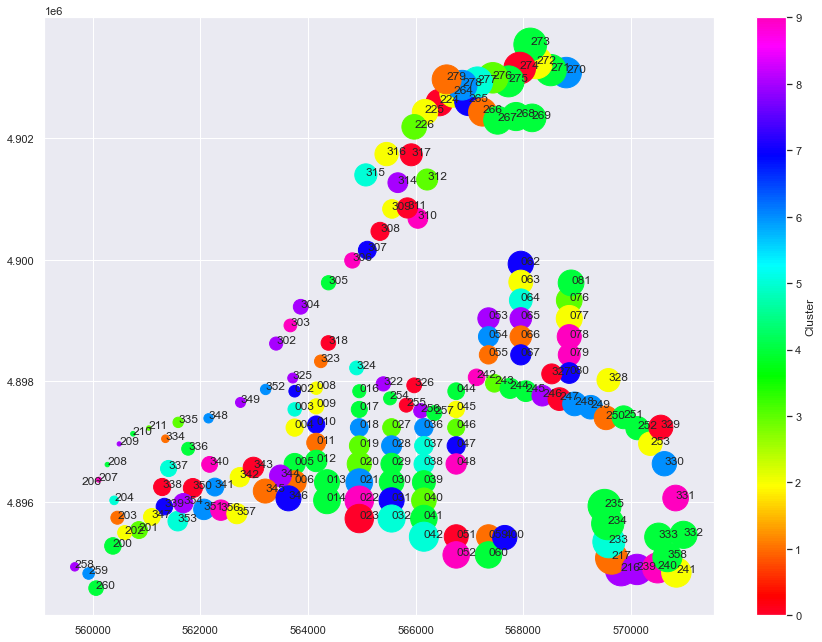

In [94]:
# biclustering column labels
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=clustering.column_labels_, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [92]:
clustering = SpectralBiclustering(n_clusters=15, random_state=0).fit(ret.precision_)
clustering.column_labels_

array([13,  1,  5,  1, 11,  3,  9, 11, 14, 11, 11, 14,  1, 11,  1, 12,  6,
        9,  3,  9,  1, 12,  1, 12,  9,  8,  8,  6,  6,  8,  5, 14,  3, 14,
        8, 11,  6, 11, 11, 14,  7,  4,  6,  8,  1,  1, 14,  5,  1,  8,  0,
        5,  4, 14, 13,  4,  6,  2,  1,  1,  3, 10, 14,  1,  1,  9,  3, 12,
        1,  1,  1,  8,  8,  1, 14,  1, 14,  1, 14, 12,  0, 12, 13,  6,  4,
       12,  1, 11,  1, 11,  1,  8,  3, 13,  1, 11,  8, 14,  1,  1,  1,  1,
        1,  1, 14,  1,  1,  1, 14,  5,  1, 13,  3,  9,  7,  9,  3,  7,  5,
        2, 10,  8,  3, 12,  1,  9, 14,  2,  0,  4,  3,  3, 10, 14, 14,  5,
        4,  5, 14, 14,  1,  1,  8, 14,  3,  3, 12, 10, 14, 12, 11,  8,  6,
        5,  9,  1,  1, 14, 11, 14,  8, 10,  6, 11, 14,  1,  9],
      dtype=int32)

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_3955/2163141238.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


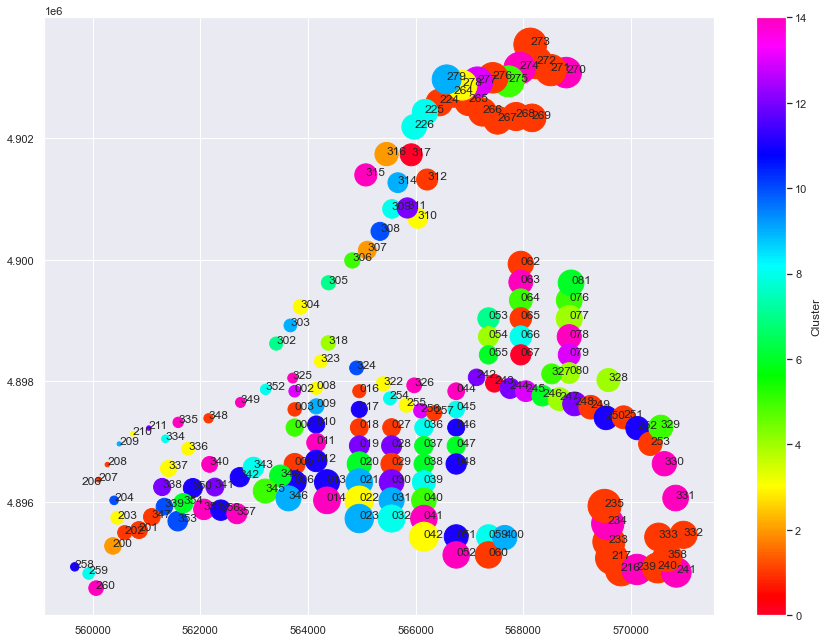

In [93]:
# biclustering column labels
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=clustering.column_labels_, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_3955/1928806541.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


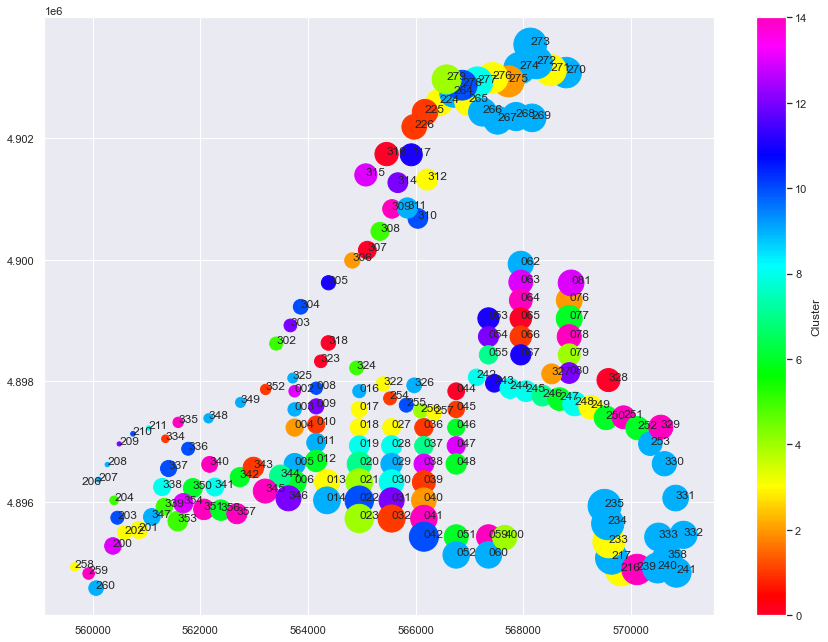

In [94]:
# biclustering column labels
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=clustering.row_labels_, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

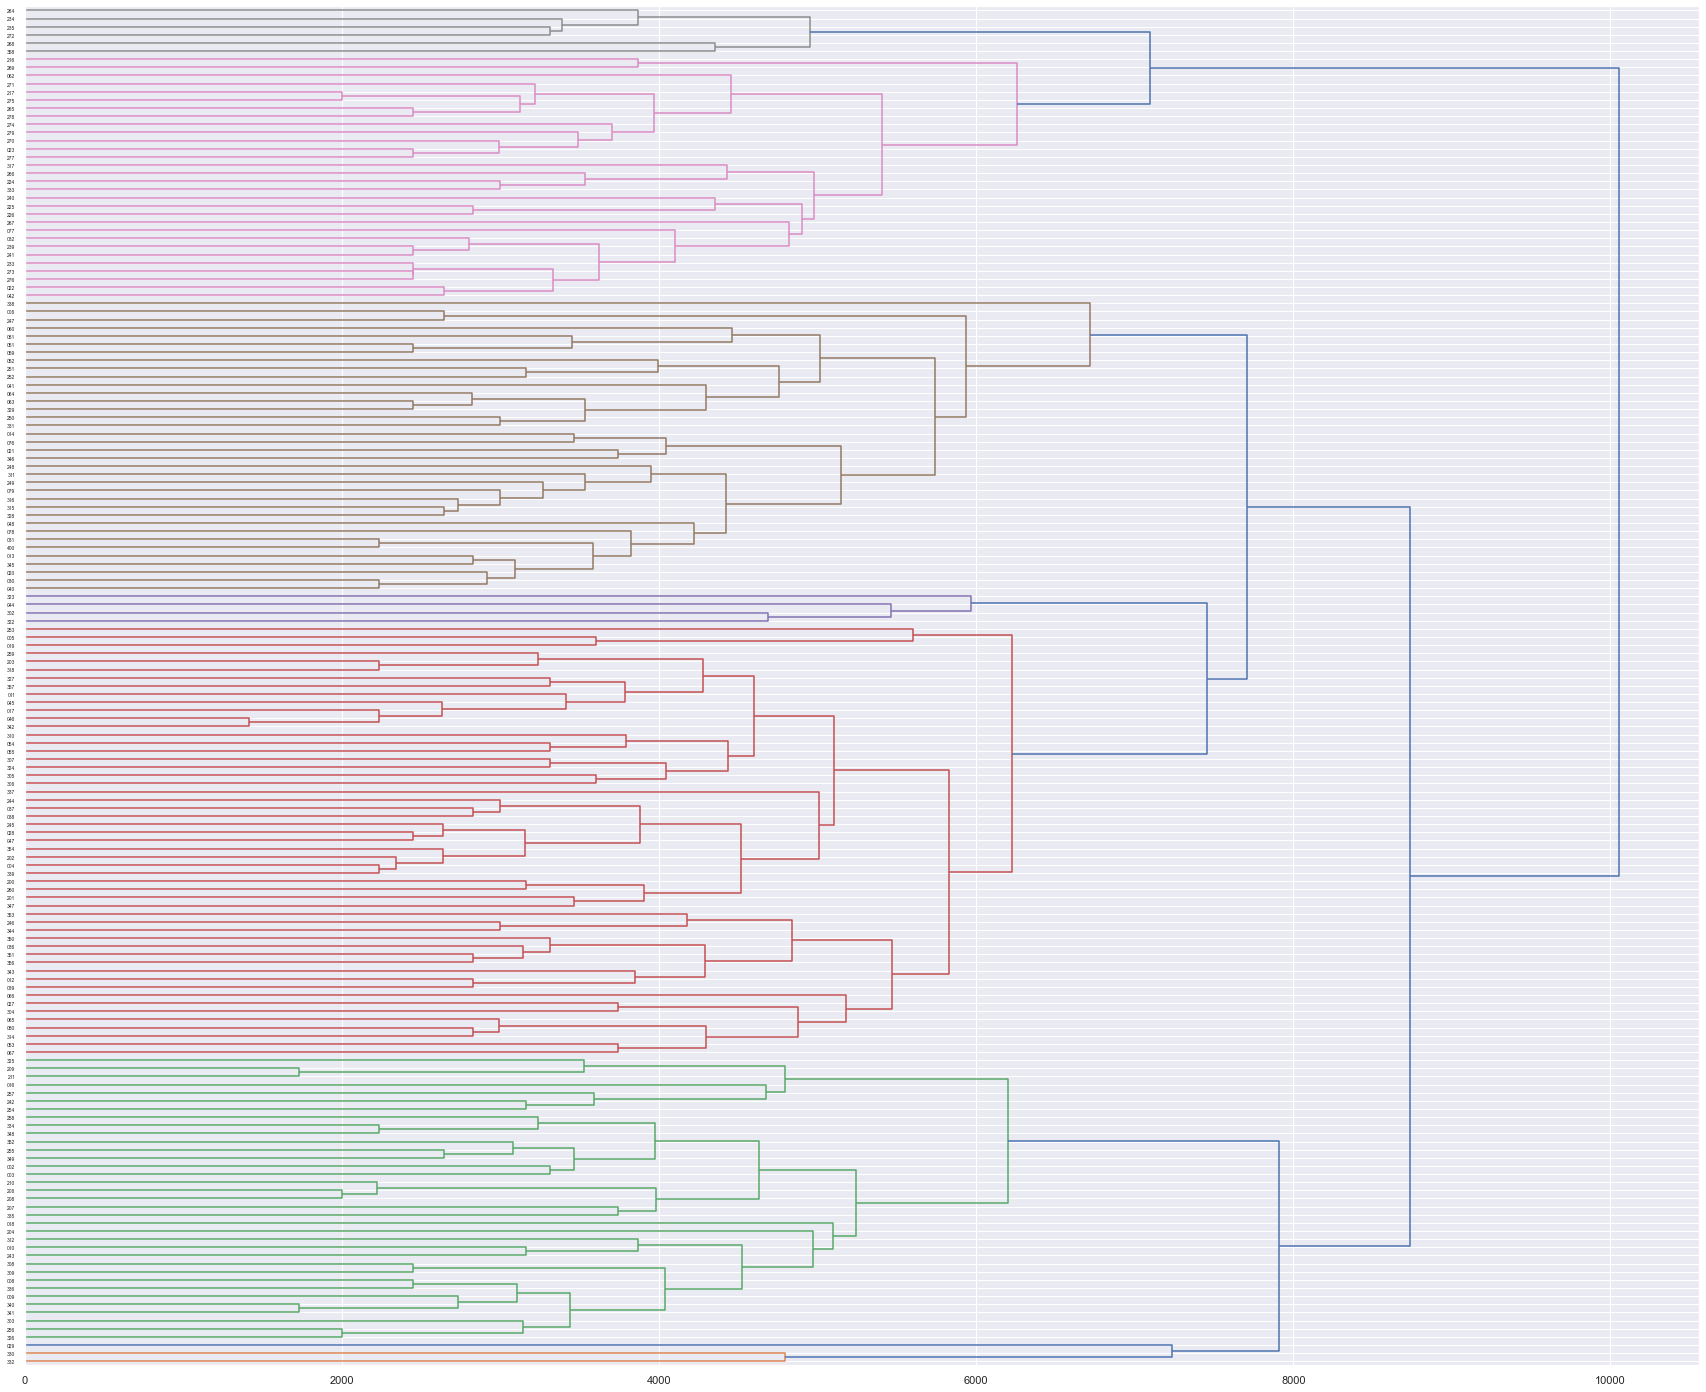

In [95]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
Z = linkage(hierarchy.distance.pdist(precision),
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [126]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=6).squeeze()
cutree1

array([0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 3, 3, 1, 1,
       4, 2, 2, 3, 1, 1, 1, 1, 2, 2, 3, 5, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       2, 3, 2, 2, 1, 1, 1, 2, 3, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 5, 0, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 3, 1, 5, 5,
       1, 0, 0, 1, 2, 2, 4, 2, 4, 3, 0, 0, 0, 1, 2, 1, 0, 0, 1, 1, 1, 2,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 3, 2])

/var/folders/97/33ss1tqx2vqdrj19qq7_s3wh0000gn/T/ipykernel_1488/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


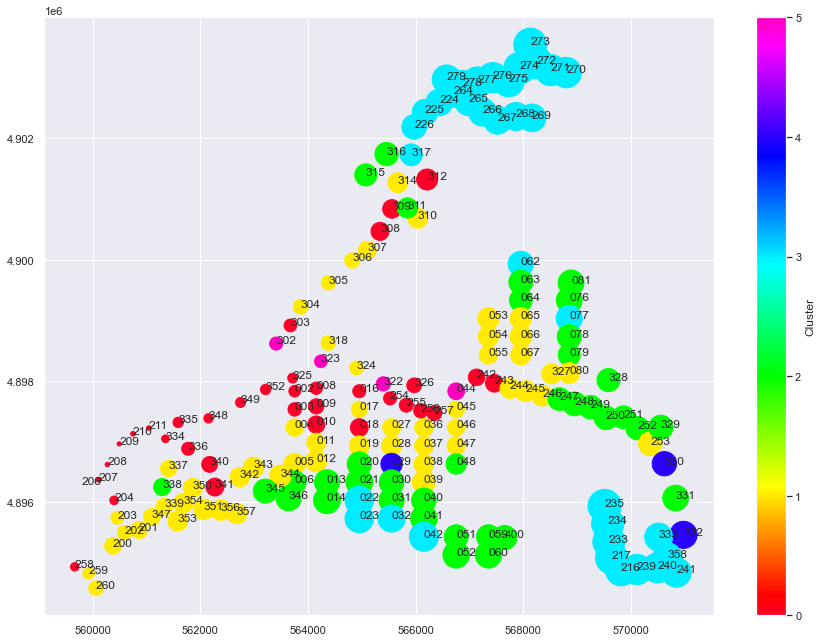

In [127]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [100]:
precision.min(), precision.max()

(0.0, 999.080931721184)

In [107]:
import scipy
import scipy.cluster.hierarchy as sch

def cluster_corr(corr_array, inplace=False):
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly 
    correlated variables are next to eachother 
    
    Parameters
    ----------
    corr_array : pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix 
        
    Returns
    -------
    pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method='complete')
    cluster_distance_threshold = pairwise_distances.max()/2
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    idx = np.argsort(idx_to_cluster_array)
    
    if not inplace:
        corr_array = corr_array.copy()
    
    if isinstance(corr_array, pd.DataFrame):
        return corr_array.iloc[idx, :].T.iloc[idx, :]
    return corr_array[idx, :][:, idx]

<AxesSubplot:>

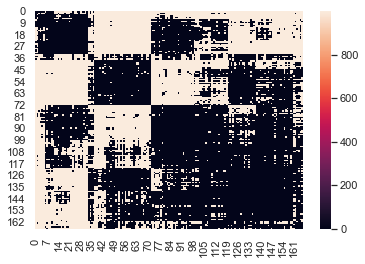

In [109]:
sns.heatmap(cluster_corr(precision))

<AxesSubplot:>

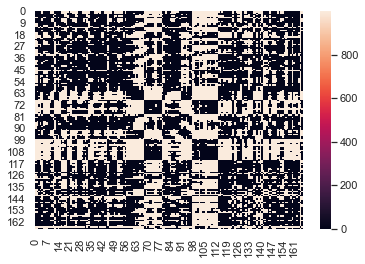

In [110]:
sns.heatmap(precision)

In [114]:
precision_two = ret.precision_.copy()
precision_two -= precision_two.min()
precision_two.max(), precision_two.min()

(1.3098159608717275, 0.0)

<AxesSubplot:>

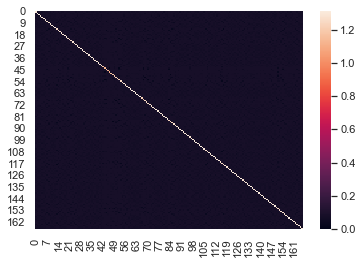

In [115]:
sns.heatmap(cluster_corr(precision_two))

<AxesSubplot:>

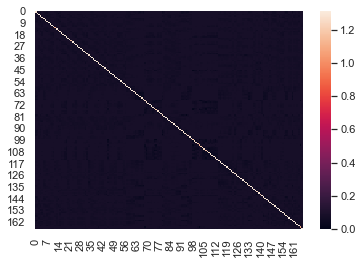

In [116]:
sns.heatmap(precision_two)

In [117]:
precision_two

array([[1.28479947, 0.05169573, 0.07244977, ..., 0.06546077, 0.08093172,
        0.08093172],
       [0.05169573, 1.25384531, 0.06961589, ..., 0.06458025, 0.08093172,
        0.08093172],
       [0.07244977, 0.06961589, 1.30725017, ..., 0.0722171 , 0.08093172,
        0.07223053],
       ...,
       [0.06546077, 0.06458025, 0.0722171 , ..., 1.29382593, 0.08093172,
        0.07584893],
       [0.08093172, 0.08093172, 0.08093172, ..., 0.08093172, 1.09627452,
        0.08093172],
       [0.08093172, 0.08093172, 0.07223053, ..., 0.07584893, 0.08093172,
        1.30792313]])